# Backtesting Demo: Historical Strategy Simulation

This notebook demonstrates the complete backtesting workflow for evaluating trading strategies.

**Components Demonstrated:**
- **BacktestEngine**: Run historical simulations with realistic execution
- **ExecutionSimulator**: Bid/ask pricing, slippage, and fees
- **BacktestResult**: Performance metrics, P&L attribution, Greeks tracking
- **BacktestReporter**: Generate reports with visualizations

**Key Insight**: Backtesting validates strategy performance with realistic execution costs before live trading.

---

> **Note: Synthetic Data**
> 
> This notebook uses **randomly generated** surfaces and signals for demonstration purposes.
> The trading signals have no real predictive power, so expect flat or negative performance.
> This is expected behavior—the goal is to validate the backtest mechanics (execution, tracking,
> metrics, reporting), not to demonstrate a profitable strategy. With real market data and
> trained models, performance would reflect actual strategy edge.

## Part 1: Setup

Import backtest components and configure the system.

In [35]:
import sys
sys.path.insert(0, '..')

from datetime import date, datetime, timezone, timedelta
from pathlib import Path
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm  # For delta calculation
np.random.seed(42)

# Backtest imports
from src.backtest import (
    BacktestEngine,
    BacktestResult,
    BacktestMetrics,
    BacktestReporter,
    ReportConfig,
    ExecutionSimulator,
    FillResult,
    calculate_metrics,
    generate_comparison_report,
)

# Strategy imports
from src.strategy import (
    Signal, SignalType, Greeks, OptionLeg, OptionRight,
    CONTRACT_MULTIPLIER,
)

# Config imports
from src.config.schema import (
    ExecutionConfig, RiskConfig, PositionManagementConfig,
    SignalThresholdConfig, SizingConfig, PricingConfig,
    PerTradeRiskConfig, RiskCapsConfig, StressConfig, KillSwitchConfig,
    ExitSignalsConfig, RebalancingConfig, DriftBandsConfig,
)

print("Backtest module loaded successfully!")
print(f"Components: BacktestEngine, BacktestResult, BacktestReporter")

Backtest module loaded successfully!
Components: BacktestEngine, BacktestResult, BacktestReporter


In [36]:
# Configuration for backtest - permissive settings for demo purposes
execution_config = ExecutionConfig(
    pricing=PricingConfig(use_mid_price=False, spread_buffer_pct=0.02),  # Use bid/ask
    signal_threshold=SignalThresholdConfig(min_edge=0.01, min_confidence=0.5),  # Low thresholds
    sizing=SizingConfig(base_contracts=2, max_contracts_per_trade=10, kelly_fraction=0.25),
    # Default slippage: 5 bps
    # Default fees: $0.65/contract
)

risk_config = RiskConfig(
    per_trade=PerTradeRiskConfig(max_loss=2000.0, max_contracts=20),  # Higher limits
    caps=RiskCapsConfig(max_abs_delta=1000.0, max_abs_vega=5000.0, max_daily_loss=10000.0),
    stress=StressConfig(spot_shocks=[-0.10, 0.10], vol_shocks=[-0.20, 0.50]),
    kill_switch=KillSwitchConfig(max_daily_loss=10000.0),  # High kill switch
)

position_management_config = PositionManagementConfig(
    exit_signals=ExitSignalsConfig(
        min_edge_retention=0.3,
        stop_loss_pct=0.8,      # Exit at 80% of max loss
        take_profit_pct=0.5,    # Exit at 50% profit
        min_dte_exit=3,
    ),
    rebalancing=RebalancingConfig(enabled=True, strategy="close_first", max_trades_per_rebalance=3),
    drift_bands=DriftBandsConfig(delta_target=0.0, delta_max_drift=200.0, vega_target=0.0, vega_max_drift=1000.0),
)

print("Configuration (permissive for demo):")
print(f"  Slippage: {execution_config.slippage.fixed_bps} bps")
print(f"  Fees: ${execution_config.fees.per_contract:.2f}/contract")
print(f"  Min edge: {execution_config.signal_threshold.min_edge:.0%}")
print(f"  Max loss per trade: ${risk_config.per_trade.max_loss:.0f}")
print(f"  Kill switch: ${risk_config.kill_switch.max_daily_loss:.0f} daily loss")

Configuration (permissive for demo):
  Slippage: 5.0 bps
  Fees: $0.65/contract
  Min edge: 1%
  Max loss per trade: $2000
  Kill switch: $10000 daily loss


## Part 2: Generate Synthetic Market Data

Create realistic options surfaces for backtesting.

In [37]:
def build_surface(as_of_date: date, underlying_price: float = 450.0, base_iv: float = 0.20) -> pd.DataFrame:
    """Build a simulated options surface with calls and puts at each strike.
    
    Uses FIXED monthly expiries AND fixed strikes to ensure option symbols
    persist across trading days. This allows proper position tracking and exit pricing.
    
    Includes wing options (10P, 10C) for SkewTrade and IronCondor structures.
    
    IMPORTANT: Delta bucket is assigned based on MONEYNESS (strike/underlying),
    not calculated delta. This ensures the same strike gets the same bucket
    across all tenors, which is required for CalendarSpread to find matching
    far options.
    """
    # Use fixed monthly expiry dates (3rd Friday convention simplified)
    fixed_expiries = [
        date(2024, 1, 19),   # Jan expiry
        date(2024, 2, 16),   # Feb expiry
        date(2024, 3, 15),   # Mar expiry
        date(2024, 4, 19),   # Apr expiry
        date(2024, 5, 17),   # May expiry
    ]
    
    # Filter to expiries that haven't passed yet
    valid_expiries = [exp for exp in fixed_expiries if exp > as_of_date]
    
    # Use FIXED strikes with EXTENDED range for wing options
    # Range must accommodate underlying price movement (~$420-$460 in simulation)
    # For 10P at underlying=$420: need strikes ≤ $386 (0.92 * 420)
    # For 10C at underlying=$460: need strikes > $497 (1.08 * 460)
    # Using $360-$540 to ensure wing options always exist
    fixed_strikes = list(range(360, 545, 5))  # 360, 365, ... 540
    
    records = []
    for expiry in valid_expiries:
        tenor = (expiry - as_of_date).days
        if tenor < 1:
            continue
            
        t = tenor / 365.0  # time to expiry in years
        
        for strike in fixed_strikes:
            # Assign delta bucket based on MONEYNESS (consistent across tenors)
            # This is critical for CalendarSpread which needs same bucket at different tenors
            moneyness_pct = strike / underlying_price
            if moneyness_pct <= 0.92:
                delta_bucket = "10P"      # Wing put (deep OTM)
            elif moneyness_pct <= 0.97:
                delta_bucket = "25P"
            elif moneyness_pct <= 1.03:
                delta_bucket = "ATM"
            elif moneyness_pct <= 1.08:
                delta_bucket = "25C"
            else:
                delta_bucket = "10C"      # Wing call (deep OTM)
            
            for right in ["C", "P"]:
                # Realistic delta calculation using Black-Scholes approximation
                log_moneyness = np.log(strike / underlying_price)
                sigma_sqrt_t = base_iv * np.sqrt(t)
                
                if sigma_sqrt_t > 0.001:
                    d1 = -log_moneyness / sigma_sqrt_t + 0.5 * sigma_sqrt_t
                else:
                    d1 = 0.0
                
                call_delta = norm.cdf(d1)
                
                if right == "C":
                    delta = call_delta
                else:
                    delta = call_delta - 1.0
                
                abs_delta = abs(delta)
                
                # IV with term structure and skew
                strike_pct = strike / underlying_price
                iv = base_iv * (1 + 0.1 * (1 - strike_pct) + 0.02 * np.sqrt(t))
                time_value = iv * np.sqrt(t) * underlying_price * 0.4
                intrinsic = max(
                    0,
                    (underlying_price - strike) if right == "C" else (strike - underlying_price),
                )
                mid_price = max(0.10, intrinsic + time_value * abs_delta)
                spread = max(0.05, mid_price * 0.03)
                
                gamma = abs_delta * (1 - abs_delta) / (underlying_price * iv * np.sqrt(t) + 0.01)
                vega = underlying_price * np.sqrt(t) * abs_delta * (1 - abs_delta) * 4
                theta = -underlying_price * iv / (2 * np.sqrt(t) * 365) * abs_delta * 0.5
                
                # FIXED symbol format - uses fixed expiry and fixed strike
                symbol = f"SPY{expiry.strftime('%y%m%d')}{right}{int(strike*1000):08d}"
                
                records.append({
                    "option_symbol": symbol,
                    "underlying_price": underlying_price,
                    "tenor_days": tenor,
                    "delta_bucket": delta_bucket,
                    "strike": float(strike),
                    "expiry": expiry,
                    "right": right,
                    "iv": round(iv, 4),
                    "bid": round(mid_price - spread / 2, 2),
                    "ask": round(mid_price + spread / 2, 2),
                    "delta": round(delta, 3),
                    "gamma": round(gamma, 6),
                    "vega": round(vega, 3),
                    "theta": round(theta, 4),
                })
    
    return pd.DataFrame(records)


def generate_signals(surface: pd.DataFrame, n_signals: int = 2, seed: int = None) -> list[Signal]:
    """Generate trading signals that are compatible with structure creation.
    
    Now includes all 4 signal types:
    - TERM_ANOMALY -> CalendarSpread
    - DIRECTIONAL_VOL -> VerticalSpread
    - SKEW_ANOMALY -> SkewTrade
    - ELEVATED_IV -> IronCondor
    
    Only generates signals for tenors that have valid far options for calendar spreads.
    """
    if seed is not None:
        np.random.seed(seed)
    
    signals = []
    # All 4 signal types
    signal_types = [
        SignalType.TERM_ANOMALY,
        SignalType.DIRECTIONAL_VOL,
        SignalType.SKEW_ANOMALY,
        SignalType.ELEVATED_IV,
    ]
    # Weights: term 25%, directional 35%, skew 20%, elevated_iv 20%
    signal_probs = [0.25, 0.35, 0.20, 0.20]
    
    # Filter to tenors that can form calendar spreads (need far tenor > near + 30)
    max_tenor = surface["tenor_days"].max()
    valid_tenors = surface[surface["tenor_days"] <= max_tenor - 30]["tenor_days"].unique()
    
    if len(valid_tenors) == 0:
        return []
    
    # Get ATM nodes for better trade execution
    tradeable_nodes = surface[
        (surface["delta_bucket"] == "ATM") & 
        (surface["tenor_days"].isin(valid_tenors))
    ]
    
    if tradeable_nodes.empty:
        return []
    
    for _ in range(n_signals):
        node = tradeable_nodes.sample(1).iloc[0]
        signal_type = signal_types[np.random.choice([0, 1, 2, 3], p=signal_probs)]
        
        # Positive edge for clearer direction
        edge = np.random.uniform(0.03, 0.08)
        
        # Confidence above min_confidence threshold (0.5) for all signal types
        # Note: ELEVATED_IV conceptually works with "neutral view" but we still need
        # confidence >= min_confidence to pass the threshold check. The iron condor
        # structure is appropriate regardless of confidence level.
        confidence = np.random.uniform(0.6, 0.9)
        
        signals.append(Signal(
            signal_type=signal_type,
            edge=edge,
            confidence=confidence,
            tenor_days=int(node["tenor_days"]),
            delta_bucket=str(node["delta_bucket"]),
            timestamp=datetime.now(timezone.utc),
        ))
    
    return signals

print("Data generation functions ready.")
print("Surface: Fixed monthly expiries (Jan-May 2024), fixed strikes ($360-$540)")
print("Signals: All 4 types - TERM_ANOMALY, DIRECTIONAL_VOL, SKEW_ANOMALY, ELEVATED_IV")
print("Distribution: Term 25%, Directional 35%, Skew 20%, ElevatedIV 20%")
print("Note: Extended strike range ensures wing options exist for all underlying prices")

Data generation functions ready.
Surface: Fixed monthly expiries (Jan-May 2024), fixed strikes ($360-$540)
Signals: All 4 types - TERM_ANOMALY, DIRECTIONAL_VOL, SKEW_ANOMALY, ELEVATED_IV
Distribution: Term 25%, Directional 35%, Skew 20%, ElevatedIV 20%
Note: Extended strike range ensures wing options exist for all underlying prices


In [38]:
# Generate historical market data (20 trading days)
start_date = date(2024, 1, 2)
end_date = date(2024, 1, 31)

surfaces = {}
signals_by_date = {}
underlying_price = 450.0

current = start_date
seed = 42
while current <= end_date:
    if current.weekday() < 5:  # Skip weekends
        # Simulate daily price movement
        underlying_price *= 1 + np.random.normal(0, 0.01)
        
        # Build surface for this day
        surfaces[current] = build_surface(current, underlying_price)
        
        # Generate 1-2 signals per trading day
        n_signals = np.random.choice([1, 2], p=[0.6, 0.4])
        signals = generate_signals(surfaces[current], n_signals, seed)
        if signals:
            signals_by_date[current] = signals
        
        seed += 1
    
    current += timedelta(days=1)

print(f"Generated {len(surfaces)} trading days of market data")
print(f"Signals generated on {len(signals_by_date)} days")
print(f"Total signals: {sum(len(s) for s in signals_by_date.values())}")
print(f"Underlying price range: ${min(s['underlying_price'].iloc[0] for s in surfaces.values()):.2f} - ${max(s['underlying_price'].iloc[0] for s in surfaces.values()):.2f}")

# Show sample surface with fixed expiries and strikes
sample_surface = list(surfaces.values())[0]
print(f"\nSample surface shape: {sample_surface.shape}")
print(f"Fixed expiries: {sorted(sample_surface['expiry'].unique())}")
print(f"Fixed strikes: {sorted(sample_surface['strike'].unique())[:5]}...{sorted(sample_surface['strike'].unique())[-3:]}")
print(f"Delta buckets: {sorted(sample_surface['delta_bucket'].unique())}")

Generated 22 trading days of market data
Signals generated on 22 days
Total signals: 33
Underlying price range: $427.98 - $453.22

Sample surface shape: (370, 14)
Fixed expiries: [datetime.date(2024, 1, 19), datetime.date(2024, 2, 16), datetime.date(2024, 3, 15), datetime.date(2024, 4, 19), datetime.date(2024, 5, 17)]
Fixed strikes: [np.float64(360.0), np.float64(365.0), np.float64(370.0), np.float64(375.0), np.float64(380.0)]...[np.float64(530.0), np.float64(535.0), np.float64(540.0)]
Delta buckets: ['10C', '10P', '25C', '25P', 'ATM']


## Part 3: Run Backtest

Execute the backtest engine over historical data.

In [39]:
# Initialize backtest engine
initial_capital = 100_000.0

engine = BacktestEngine(
    start_date=start_date,
    end_date=end_date,
    initial_capital=initial_capital,
    execution_config=execution_config,
    risk_config=risk_config,
    position_management_config=position_management_config,
)

print(f"Backtest Engine initialized:")
print(f"  Period: {start_date} to {end_date}")
print(f"  Initial capital: ${initial_capital:,.0f}")

Backtest Engine initialized:
  Period: 2024-01-02 to 2024-01-31
  Initial capital: $100,000


In [40]:
# Run the backtest
print("Running backtest...")
print("=" * 60)

result = engine.run_backtest(
    surfaces=surfaces,
    signals_by_date=signals_by_date,
)

print("=" * 60)
print(f"Backtest complete!")
print(f"  Run ID: {result.run_id}")
print(f"  Run time: {result.run_time_seconds:.2f}s")

Running backtest...
Backtest complete!
  Run ID: bt-2105eb56
  Run time: 0.05s


## Part 4: Analyze Results

Examine backtest performance using BacktestResult methods.

In [41]:
# Print summary
print(result.summary())


Backtest Summary: bt-2105eb56
Period: 2024-01-02 to 2024-01-31
Initial Capital: $100,000.00
Final Equity: $98,574.28
Run Time: 0.05s

Performance
-----------
Total Return: -1.43%
Annualized Return: -15.17%
Sharpe Ratio: -6.94
Sortino Ratio: -6.62
Max Drawdown: 1.43%

Trades
------
Total Trades: 10
Win Rate: 40.0%
Avg Trade P&L: $-142.57
Profit Factor: 0.10
Avg Holding Period: 2.2 days

Execution
---------
Total Fees: $31.20
Total Slippage: $17.92



In [42]:
# Access detailed metrics
m = result.metrics

print("PERFORMANCE METRICS")
print("=" * 40)
print(f"Total Return:        {m.total_return_pct:+.2f}%")
print(f"Annualized Return:   {m.annualized_return_pct:+.2f}%")
print(f"Sharpe Ratio:        {m.sharpe_ratio:.3f}")
print(f"Sortino Ratio:       {m.sortino_ratio:.3f}")
print(f"Calmar Ratio:        {m.calmar_ratio:.3f}")
print()
print("DRAWDOWN ANALYSIS")
print("=" * 40)
print(f"Max Drawdown:        {m.max_drawdown_pct:.2f}%")
print(f"Max DD Duration:     {m.max_drawdown_duration_days} days")
print(f"Avg Drawdown:        {m.avg_drawdown_pct:.2f}%")
print()
print("TRADE STATISTICS")
print("=" * 40)
print(f"Total Trades:        {m.total_trades}")
print(f"Win Rate:            {m.win_rate:.1f}%")
print(f"Profit Factor:       {m.profit_factor:.2f}")
print(f"Avg Trade P&L:       ${m.avg_trade_pnl:,.2f}")
print(f"Max Win:             ${m.max_win:,.2f}")
print(f"Max Loss:            ${m.max_loss:,.2f}")
print()
print("RISK METRICS")
print("=" * 40)
print(f"VaR (95%):           ${m.var_95:,.2f}")
print(f"CVaR (95%):          ${m.cvar_95:,.2f}")
print(f"Daily P&L Std:       ${m.daily_pnl_std:,.2f}")
print()
print("EXECUTION COSTS")
print("=" * 40)
print(f"Total Fees:          ${m.total_fees:,.2f}")
print(f"Total Slippage:      ${m.total_slippage:,.2f}")
print(f"Cost as % of P&L:    {m.total_commission_pct:.2f}%")

PERFORMANCE METRICS
Total Return:        -1.43%
Annualized Return:   -15.17%
Sharpe Ratio:        -6.941
Sortino Ratio:       -6.622
Calmar Ratio:        -10.638

DRAWDOWN ANALYSIS
Max Drawdown:        1.43%
Max DD Duration:     20 days
Avg Drawdown:        0.62%

TRADE STATISTICS
Total Trades:        10
Win Rate:            40.0%
Profit Factor:       0.10
Avg Trade P&L:       $-142.57
Max Win:             $58.80
Max Loss:            $-456.29

RISK METRICS
VaR (95%):           $-370.81
CVaR (95%):          $-414.95
Daily P&L Std:       $148.22

EXECUTION COSTS
Total Fees:          $31.20
Total Slippage:      $17.92
Cost as % of P&L:    3.57%


In [43]:
# Examine portfolio history
portfolio_df = result.to_portfolio_df()
print(f"Portfolio history: {len(portfolio_df)} snapshots")
print()
portfolio_df.head(10)

Portfolio history: 22 snapshots



,timestamp,date,cash,positions_value,total_equity,unrealized_pnl,realized_pnl,daily_pnl,net_delta,net_gamma,net_vega,net_theta,open_positions,entries_today,exits_today
0,2024-01-02 00:00:00+00:00,2024-01-02,100000.0000,0.0,100000.0000,0.0,0.0000,0.0000,0.0,0.000,0.0,0.00,0,0,0
1,2024-01-03 00:00:00+00:00,2024-01-03,100000.0000,0.0,100000.0000,0.0,0.0000,0.0000,0.0,0.000,0.0,0.00,0,0,0
2,2024-01-04 00:00:00+00:00,2024-01-04,98923.4165,1024.0,99947.4165,0.0,0.0000,0.0000,21.4,-0.221,-1421.5,-6.51,1,1,0
3,2024-01-05 00:00:00+00:00,2024-01-05,98850.8160,1123.0,99973.8160,0.0,-2200.9285,47.7615,13.0,-0.072,-1292.8,-2.38,1,1,1
4,2024-01-08 00:00:00+00:00,2024-01-08,99730.1115,0.0,99730.1115,0.0,-4277.1695,-317.6500,0.0,0.000,0.0,0.00,0,0,1
5,2024-01-09 00:00:00+00:00,2024-01-09,97604.8215,2013.0,99617.8215,0.0,-4277.1695,0.0000,40.1,-0.441,-2608.4,-12.23,2,2,0
6,2024-01-10 00:00:00+00:00,2024-01-10,99837.1185,0.0,99837.1185,0.0,-8634.7565,107.0070,0.0,0.000,0.0,0.00,0,0,2
7,2024-01-11 00:00:00+00:00,2024-01-11,99837.1185,0.0,99837.1185,0.0,-8634.7565,0.0000,0.0,0.000,0.0,0.00,0,0,0
8,2024-01-12 00:00:00+00:00,2024-01-12,99837.1185,0.0,99837.1185,0.0,-8634.7565,0.0000,0.0,0.000,0.0,0.00,0,0,0
9,2024-01-15 00:00:00+00:00,2024-01-15,99837.1185,0.0,99837.1185,0.0,-8634.7565,0.0000,0.0,0.000,0.0,0.00,0,0,0


In [44]:
# Examine trades
trades_df = result.to_trades_df()
print(f"Total trade records: {len(trades_df)}")
print()
if not trades_df.empty:
    display(trades_df[["timestamp", "trade_type", "structure_type", "gross_premium", "fees", "slippage", "net_premium"]].head(10))

Total trade records: 20



,timestamp,trade_type,structure_type,gross_premium,fees,slippage,net_premium
0,2024-01-04 00:00:00+00:00,ENTRY,VerticalSpread,1077.8835,1.3,0.8835,1076.5835
1,2024-01-05 00:00:00+00:00,EXIT,VerticalSpread,-1123.0450,1.3,0.9550,47.7615
2,2024-01-05 00:00:00+00:00,ENTRY,VerticalSpread,1198.2455,1.3,1.2455,1196.9455
3,2024-01-08 00:00:00+00:00,EXIT,VerticalSpread,-877.9955,1.3,1.0045,-317.6500
4,2024-01-09 00:00:00+00:00,ENTRY,VerticalSpread,1072.0915,1.3,1.0915,1070.7915
5,2024-01-09 00:00:00+00:00,ENTRY,VerticalSpread,1055.7985,1.3,0.7985,1054.4985
6,2024-01-10 00:00:00+00:00,EXIT,VerticalSpread,-1117.6955,1.3,1.3045,48.2040
7,2024-01-10 00:00:00+00:00,EXIT,VerticalSpread,-1112.0015,1.3,0.9985,58.8030
8,2024-01-16 00:00:00+00:00,ENTRY,SkewTrade,98.2610,2.6,0.2610,95.6610
9,2024-01-17 00:00:00+00:00,EXIT,SkewTrade,-98.7315,2.6,0.2685,5.6705


In [45]:
# Greeks timeseries
greeks_df = result.to_greeks_df()
print(f"Greeks timeseries: {len(greeks_df)} snapshots")
print()
greeks_df.head(10)

Greeks timeseries: 22 snapshots



,timestamp,date,net_delta,net_gamma,net_vega,net_theta
0,2024-01-02 00:00:00+00:00,2024-01-02,0.0,0.000,0.0,0.00
1,2024-01-03 00:00:00+00:00,2024-01-03,0.0,0.000,0.0,0.00
2,2024-01-04 00:00:00+00:00,2024-01-04,21.4,-0.221,-1421.5,-6.51
3,2024-01-05 00:00:00+00:00,2024-01-05,13.0,-0.072,-1292.8,-2.38
4,2024-01-08 00:00:00+00:00,2024-01-08,0.0,0.000,0.0,0.00
5,2024-01-09 00:00:00+00:00,2024-01-09,40.1,-0.441,-2608.4,-12.23
6,2024-01-10 00:00:00+00:00,2024-01-10,0.0,0.000,0.0,0.00
7,2024-01-11 00:00:00+00:00,2024-01-11,0.0,0.000,0.0,0.00
8,2024-01-12 00:00:00+00:00,2024-01-12,0.0,0.000,0.0,0.00
9,2024-01-15 00:00:00+00:00,2024-01-15,0.0,0.000,0.0,0.00


## Part 5: Visualizations

Generate performance plots using matplotlib.

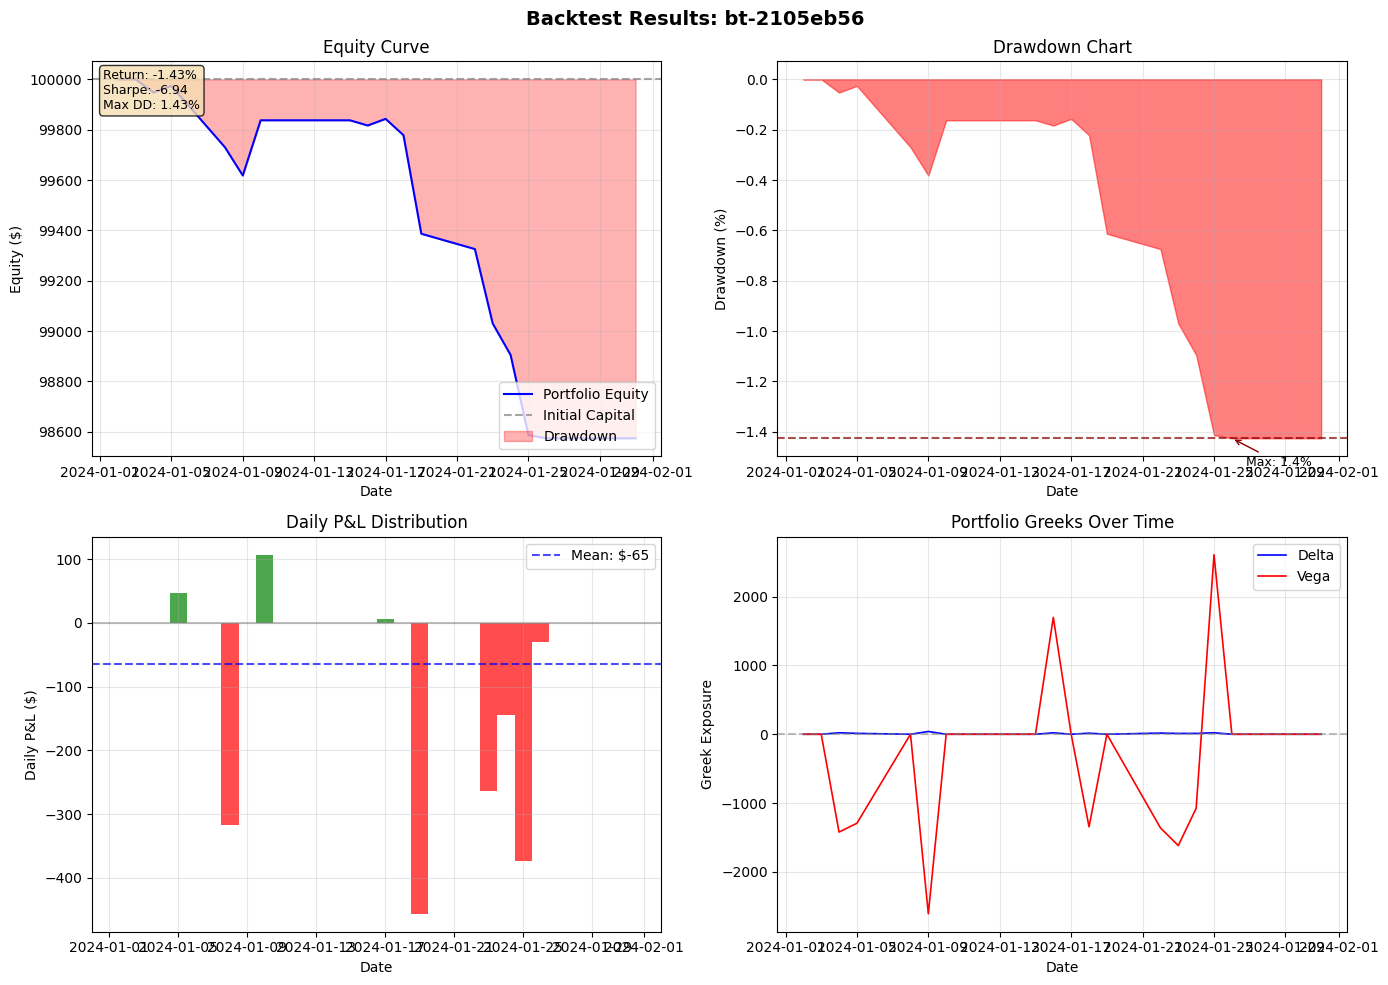

In [46]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Backtest Results: {result.run_id}", fontsize=14, fontweight="bold")

# 1. Equity Curve
ax = axes[0, 0]
if not portfolio_df.empty:
    dates = pd.to_datetime(portfolio_df["date"])
    equity = portfolio_df["total_equity"]
    running_max = equity.cummax()
    
    ax.plot(dates, equity, "b-", linewidth=1.5, label="Portfolio Equity")
    ax.axhline(y=initial_capital, color="gray", linestyle="--", alpha=0.7, label="Initial Capital")
    ax.fill_between(dates, equity, running_max, alpha=0.3, color="red", label="Drawdown")
    
    # Metrics annotation
    textstr = f"Return: {m.total_return_pct:+.2f}%\nSharpe: {m.sharpe_ratio:.2f}\nMax DD: {m.max_drawdown_pct:.2f}%"
    props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9, verticalalignment="top", bbox=props)

ax.set_xlabel("Date")
ax.set_ylabel("Equity ($)")
ax.set_title("Equity Curve")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# 2. Drawdown Chart
ax = axes[0, 1]
if not portfolio_df.empty:
    drawdown = (equity - running_max) / running_max * 100
    ax.fill_between(dates, drawdown, 0, color="red", alpha=0.5)
    ax.axhline(y=-m.max_drawdown_pct, color="darkred", linestyle="--", alpha=0.7)
    
    # Annotate max drawdown
    max_dd_idx = drawdown.idxmin()
    ax.annotate(f"Max: {m.max_drawdown_pct:.1f}%",
                xy=(dates.iloc[max_dd_idx], drawdown.iloc[max_dd_idx]),
                xytext=(10, -20), textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="->", color="darkred"))

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown Chart")
ax.grid(True, alpha=0.3)

# 3. Daily P&L
ax = axes[1, 0]
if not portfolio_df.empty:
    daily_pnl = portfolio_df["daily_pnl"]
    colors = ["green" if x >= 0 else "red" for x in daily_pnl]
    ax.bar(dates, daily_pnl, color=colors, alpha=0.7, width=1)
    ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)
    ax.axhline(y=daily_pnl.mean(), color="blue", linestyle="--", alpha=0.7, label=f"Mean: ${daily_pnl.mean():.0f}")

ax.set_xlabel("Date")
ax.set_ylabel("Daily P&L ($)")
ax.set_title("Daily P&L Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Greeks Exposure
ax = axes[1, 1]
if not greeks_df.empty:
    dates = pd.to_datetime(greeks_df["date"])
    ax.plot(dates, greeks_df["net_delta"], "b-", label="Delta", linewidth=1.2)
    ax.plot(dates, greeks_df["net_vega"], "r-", label="Vega", linewidth=1.2)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

ax.set_xlabel("Date")
ax.set_ylabel("Greek Exposure")
ax.set_title("Portfolio Greeks Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 6: Report Generation

Use BacktestReporter to generate a complete report with all outputs.

In [47]:
# Generate full report (to temp directory)
with tempfile.TemporaryDirectory() as tmpdir:
    config = ReportConfig(
        output_dir=Path(tmpdir),
        include_plots=True,
        plot_format="png",
        plot_dpi=100,
        figsize=(12, 8),
    )
    
    reporter = BacktestReporter(config)
    outputs = reporter.generate_report(result)
    
    print("Generated Report Files:")
    print("=" * 50)
    for name, path in outputs.items():
        size = path.stat().st_size if path.exists() else 0
        print(f"  {name:20s}: {path.name} ({size:,} bytes)")
    
    # Read and display summary
    print("\n" + "=" * 50)
    print("REPORT SUMMARY")
    print("=" * 50)
    if "summary_txt" in outputs:
        print(outputs["summary_txt"].read_text())

Generated Report Files:
  trades_csv          : bt-2105eb56_trades.csv (4,481 bytes)
  portfolio_csv       : bt-2105eb56_portfolio.csv (3,220 bytes)
  greeks_csv          : bt-2105eb56_greeks.csv (1,693 bytes)
  summary_txt         : bt-2105eb56_summary.txt (1,552 bytes)
  equity_plot         : bt-2105eb56_equity.png (54,842 bytes)
  drawdown_plot       : bt-2105eb56_drawdown.png (59,026 bytes)
  greeks_plot         : bt-2105eb56_greeks.png (98,385 bytes)
  trades_plot         : bt-2105eb56_trades.png (83,617 bytes)

REPORT SUMMARY

                         BACKTEST REPORT: bt-2105eb56

OVERVIEW
--------
Period:              2024-01-02 to 2024-01-31
Trading Days:        22
Initial Capital:     $100,000.00
Final Equity:        $98,574.28
Net P&L:             $-1,425.72
Run Time:            0.05s

PERFORMANCE METRICS
-------------------
Total Return:        -1.43%
Annualized Return:   -15.17%
Sharpe Ratio:        -6.941
Sortino Ratio:       -6.622
Calmar Ratio:        -10.638

DRAWDOWN A

In [48]:
# Export CSVs to examine
with tempfile.TemporaryDirectory() as tmpdir:
    # Export trades
    trades_path = Path(tmpdir) / "trades.csv"
    result.export_trades_csv(str(trades_path))
    
    # Export portfolio
    portfolio_path = Path(tmpdir) / "portfolio.csv"
    result.export_portfolio_csv(str(portfolio_path))
    
    # Export Greeks
    greeks_path = Path(tmpdir) / "greeks.csv"
    result.export_greeks_csv(str(greeks_path))
    
    print("Exported CSVs:")
    
    # Handle empty trades file gracefully
    trades_content = trades_path.read_text()
    if trades_content.strip():
        print(f"  trades.csv:    {len(pd.read_csv(trades_path))} rows")
    else:
        print(f"  trades.csv:    0 rows (no trades)")
    
    print(f"  portfolio.csv: {len(pd.read_csv(portfolio_path))} rows")
    print(f"  greeks.csv:    {len(pd.read_csv(greeks_path))} rows")

Exported CSVs:
  trades.csv:    20 rows
  portfolio.csv: 22 rows
  greeks.csv:    22 rows


## Part 7: Compare Multiple Backtests

Run backtests with different parameters and compare results.

In [49]:
# Run backtests with different risk configs
results = []

# Conservative config
conservative_risk = RiskConfig(
    per_trade=PerTradeRiskConfig(max_loss=500.0, max_contracts=5),
    caps=RiskCapsConfig(max_abs_delta=200.0, max_abs_vega=1000.0, max_daily_loss=2000.0),
    stress=StressConfig(spot_shocks=[-0.10, 0.10], vol_shocks=[-0.20, 0.50]),
    kill_switch=KillSwitchConfig(max_daily_loss=2000.0),
)

engine_conservative = BacktestEngine(
    start_date=start_date,
    end_date=end_date,
    initial_capital=initial_capital,
    execution_config=execution_config,
    risk_config=conservative_risk,
    position_management_config=position_management_config,
)

result_conservative = engine_conservative.run_backtest(
    surfaces=surfaces,
    signals_by_date=signals_by_date,
)
results.append(result_conservative)
print(f"Conservative ({result_conservative.run_id}): Return {result_conservative.metrics.total_return_pct:+.2f}%, Sharpe {result_conservative.metrics.sharpe_ratio:.2f}")

# Aggressive config
aggressive_risk = RiskConfig(
    per_trade=PerTradeRiskConfig(max_loss=2000.0, max_contracts=20),
    caps=RiskCapsConfig(max_abs_delta=1000.0, max_abs_vega=5000.0, max_daily_loss=10000.0),
    stress=StressConfig(spot_shocks=[-0.10, 0.10], vol_shocks=[-0.20, 0.50]),
    kill_switch=KillSwitchConfig(max_daily_loss=10000.0),
)

engine_aggressive = BacktestEngine(
    start_date=start_date,
    end_date=end_date,
    initial_capital=initial_capital,
    execution_config=execution_config,
    risk_config=aggressive_risk,
    position_management_config=position_management_config,
)

result_aggressive = engine_aggressive.run_backtest(
    surfaces=surfaces,
    signals_by_date=signals_by_date,
)
results.append(result_aggressive)
print(f"Aggressive ({result_aggressive.run_id}): Return {result_aggressive.metrics.total_return_pct:+.2f}%, Sharpe {result_aggressive.metrics.sharpe_ratio:.2f}")

Conservative (bt-2be7228f): Return +0.00%, Sharpe 0.00
Aggressive (bt-92b58101): Return -1.43%, Sharpe -6.94


In [50]:
# Generate comparison report
with tempfile.TemporaryDirectory() as tmpdir:
    output_dir = Path(tmpdir)
    comparison_path = generate_comparison_report(results, output_dir)
    
    comparison_df = pd.read_csv(comparison_path)
    print("Comparison Report:")
    print("=" * 70)
    display(comparison_df.T)

Comparison Report:


,0,1
run_id,bt-2be7228f,bt-92b58101
start_date,2024-01-02,2024-01-02
end_date,2024-01-31,2024-01-31
total_return_pct,0.0,-1.425719
sharpe_ratio,0.0,-6.940661
sortino_ratio,0.0,-6.621979
max_drawdown_pct,0.0,1.425719
total_trades,0,10
win_rate,0.0,40.0
profit_factor,0.0,0.101149


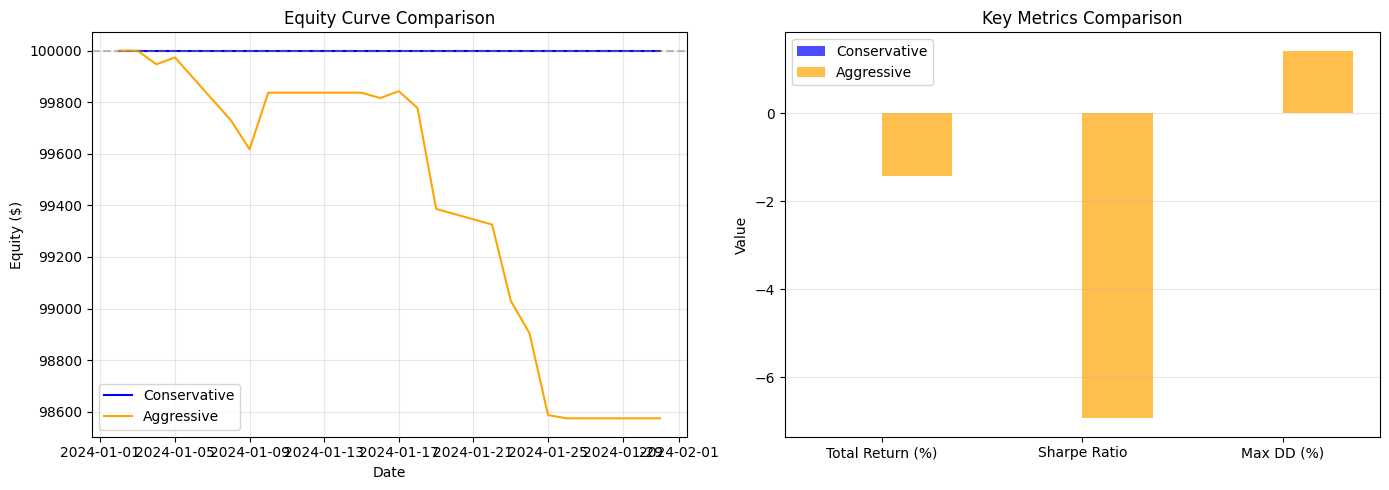

In [51]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Equity curves comparison
ax = axes[0]
colors = ["blue", "orange"]
labels = ["Conservative", "Aggressive"]

for i, res in enumerate(results):
    portfolio_df = res.to_portfolio_df()
    if not portfolio_df.empty:
        dates = pd.to_datetime(portfolio_df["date"])
        equity = portfolio_df["total_equity"]
        ax.plot(dates, equity, color=colors[i], linewidth=1.5, label=labels[i])

ax.axhline(y=initial_capital, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Equity ($)")
ax.set_title("Equity Curve Comparison")
ax.legend()
ax.grid(True, alpha=0.3)

# Metrics comparison
ax = axes[1]
metrics_names = ["Total Return (%)", "Sharpe Ratio", "Max DD (%)"]
conservative_vals = [result_conservative.metrics.total_return_pct, 
                     result_conservative.metrics.sharpe_ratio,
                     result_conservative.metrics.max_drawdown_pct]
aggressive_vals = [result_aggressive.metrics.total_return_pct,
                   result_aggressive.metrics.sharpe_ratio,
                   result_aggressive.metrics.max_drawdown_pct]

x = np.arange(len(metrics_names))
width = 0.35
ax.bar(x - width/2, conservative_vals, width, label="Conservative", color="blue", alpha=0.7)
ax.bar(x + width/2, aggressive_vals, width, label="Aggressive", color="orange", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylabel("Value")
ax.set_title("Key Metrics Comparison")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the complete backtesting workflow:

1. **Configuration**: Set up execution, risk, and position management parameters
2. **Data Generation**: Create synthetic market surfaces and signals for all 4 structure types:
   - `TERM_ANOMALY` -> CalendarSpread
   - `DIRECTIONAL_VOL` -> VerticalSpread
   - `SKEW_ANOMALY` -> SkewTrade
   - `ELEVATED_IV` -> IronCondor
3. **Backtest Execution**: Run BacktestEngine over historical data
4. **Result Analysis**: Access metrics, trades, portfolio history, and Greeks
5. **Visualization**: Generate equity curves, drawdown charts, and P&L analysis
6. **Report Generation**: Use BacktestReporter for comprehensive reports
7. **Comparison**: Compare multiple backtest runs with different parameters

**Key Takeaways:**
- Realistic execution costs (fees + slippage) significantly impact returns
- Risk limits prevent catastrophic losses but may reduce opportunities
- Sharpe ratio and max drawdown are key metrics for strategy evaluation
- Multiple backtest runs help optimize parameters before live trading